<a href="https://colab.research.google.com/github/bbangsberg/Apple/blob/main/Apple_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


url = "https://raw.githubusercontent.com/bbangsberg/Apple/02838f380bfe0dbaa3bb7f1696b0baa3a86bb792/AAPL_2012-06-21_34200000_37800000_message_50.csv"


df = pd.read_csv(
    url,
    header=None,
    names=[
        "time",
        "event_type",
        "order_id",
        "size",
        "price",
        "direction"
    ]
)


print("=" * 60)
print("First 10 rows")
print("=" * 60)
print(df.head(10))

print("\n")

print("=" * 60)
print("Shape")
print("=" * 60)
print(df.shape)

print("\n")

print("=" * 60)
print("Column Types")
print("=" * 60)
print(df.dtypes)

print("\n")

print("=" * 60)
print("Missing Values")
print("=" * 60)
print(df.isnull().sum())

print("\n")

print("=" * 60)
print("Event Type Counts")
print("=" * 60)
print(df["event_type"].value_counts().sort_index())

print("\n")

print("=" * 60)
print("Direction Counts")
print("=" * 60)
print(df["direction"].value_counts())

print("\n")

print("=" * 60)
print("Summary Statistics")
print("=" * 60)
print(df.describe())

First 10 rows
           time  event_type  order_id  size    price  direction
0  34200.004241           1  16113575    18  5853300          1
1  34200.004261           1  16113584    18  5853200          1
2  34200.004447           1  16113594    18  5853100          1
3  34200.025552           1  16120456    18  5859100         -1
4  34200.025580           1  16120480    18  5859200         -1
5  34200.025613           1  16120503    18  5859300         -1
6  34200.050241           1  16127688   100  5850000          1
7  34200.074199           3  13919004   100  5876500         -1
8  34200.074256           3  13919027   200  5876500         -1
9  34200.074293           3  13919011   860  5876500         -1


Shape
(91997, 6)


Column Types
time          float64
event_type      int64
order_id        int64
size            int64
price           int64
direction       int64
dtype: object


Missing Values
time          0
event_type    0
order_id      0
size          0
price         0
direc

In [2]:
df.head()

,time,event_type,order_id,size,price,direction
0,34200.004241,1,16113575,18,5853300,1
1,34200.004261,1,16113584,18,5853200,1
2,34200.004447,1,16113594,18,5853100,1
3,34200.025552,1,16120456,18,5859100,-1
4,34200.025580,1,16120480,18,5859200,-1


In [3]:
df.shape

(91997, 6)

In [4]:
df.head(10)

,time,event_type,order_id,size,price,direction
0,34200.004241,1,16113575,18,5853300,1
1,34200.004261,1,16113584,18,5853200,1
2,34200.004447,1,16113594,18,5853100,1
3,34200.025552,1,16120456,18,5859100,-1
4,34200.025580,1,16120480,18,5859200,-1
5,34200.025613,1,16120503,18,5859300,-1
6,34200.050241,1,16127688,100,5850000,1
7,34200.074199,3,13919004,100,5876500,-1
8,34200.074256,3,13919027,200,5876500,-1
9,34200.074293,3,13919011,860,5876500,-1


In [6]:
import numpy as np

df = df.copy()

# convert LOBSTER time (seconds after midnight) → nanoseconds
df["time_nanos"] = (df["time"] * 1e9).astype(np.int64)

In [7]:
def classify_event(row):

    t = row["event_type"]
    d = row["direction"]

    # 1 = limit order
    if t == 1:
        return 1 if d == 1 else 2   # limit bid / limit ask

    # 2–3 = cancellations
    if t in (2, 3):
        return 5 if d == 1 else 6   # bid cancel / ask cancel

    # 4–6 = executions (market orders)
    if t in (4, 5, 6):
        return 3 if d == 1 else 4   # market buy / market sell

    return None


df["event"] = df.apply(classify_event, axis=1)

df = df.dropna(subset=["event"])
df["event"] = df["event"].astype(int)

In [8]:
def classify_event(row):

    t = row["event_type"]
    d = row["direction"]

    # 1 = limit order
    if t == 1:
        return 1 if d == 1 else 2   # limit bid / limit ask

    # 2–3 = cancellations
    if t in (2, 3):
        return 5 if d == 1 else 6   # bid cancel / ask cancel

    # 4–6 = executions (market orders)
    if t in (4, 5, 6):
        return 3 if d == 1 else 4   # market buy / market sell

    return None


df["event"] = df.apply(classify_event, axis=1)

df = df.dropna(subset=["event"])
df["event"] = df["event"].astype(int)

In [9]:
df["notional"] = df["price"] * df["size"]

In [10]:
BAR_SIZE = 60 * 1e9  # 1 minute in nanoseconds

df["bar"] = (df["time_nanos"] // BAR_SIZE).astype(np.int64)
df["bar"] = df["bar"] - df["bar"].min()

In [11]:
features = df.pivot_table(
    index="bar",
    columns="event",
    values="size",
    aggfunc="count",
    fill_value=0
)

# ensure all 6 event types exist
for i in range(1, 7):
    if i not in features.columns:
        features[i] = 0

features = features[[1,2,3,4,5,6]]
features.columns = [
    "limit_bid",
    "limit_ask",
    "market_buy",
    "market_sell",
    "cancel_bid",
    "cancel_ask"
]

In [12]:
qty = df.groupby("bar")["size"].sum()
notional = df.groupby("bar")["notional"].sum()

features["qty"] = qty
features["notional"] = notional
features = features.fillna(0)

In [13]:
features["ofi"] = (
    features["limit_bid"] + features["market_buy"]
    - features["limit_ask"] - features["market_sell"]
)

In [14]:
def ewma(x, alpha=0.05):
    out = np.zeros_like(x, dtype=float)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = alpha * x[i] + (1 - alpha) * out[i - 1]
    return out


lambda_df = pd.DataFrame(index=features.index)

for col in ["limit_bid","limit_ask","market_buy","market_sell","cancel_bid","cancel_ask"]:
    lambda_df[col] = ewma(features[col].values)

In [15]:
features["mid_proxy"] = features["market_buy"] - features["market_sell"]
features["return"] = features["mid_proxy"].diff().fillna(0)

In [16]:
X = pd.concat([features, lambda_df.add_prefix("lambda_")], axis=1)
y = features["return"].shift(-1).fillna(0)

In [17]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X[:-1], y[:-1])

pred = model.predict(X[:-1])

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.18409e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


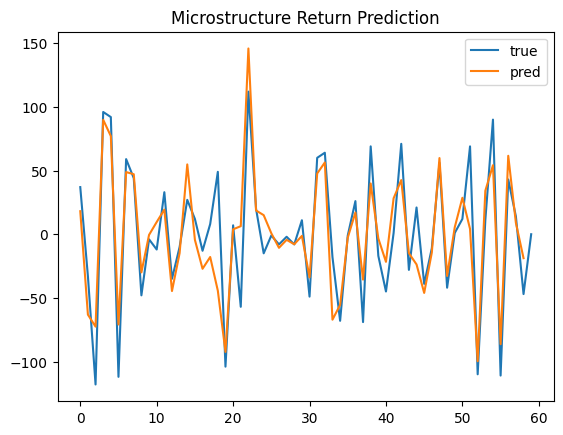

In [18]:
import matplotlib.pyplot as plt

plt.plot(y.values, label="true")
plt.plot(pred, label="pred")
plt.legend()
plt.title("Microstructure Return Prediction")
plt.show()

In [20]:
from collections import defaultdict
import numpy as np


class LimitOrderBook:

    def __init__(self):

        # price → order_id → size
        self.bids = defaultdict(dict)
        self.asks = defaultdict(dict)

        self.best_bid = 0
        self.best_ask = np.inf

    def update_best(self):

        self.best_bid = max(self.bids.keys()) if self.bids else 0
        self.best_ask = min(self.asks.keys()) if self.asks else np.inf

    def add_limit(self, side, price, order_id, size):

        book = self.bids if side == 1 else self.asks

        book[price][order_id] = size

        self.update_best()


    def cancel(self, side, price, order_id, size):

        book = self.bids if side == 1 else self.asks

        if price in book and order_id in book[price]:

            book[price][order_id] -= size

            if book[price][order_id] <= 0:
                del book[price][order_id]

            if len(book[price]) == 0:
                del book[price]

        self.update_best()


    def execute_market(self, side, size):

        remaining = size

        if side == 1:
            book = self.asks
            prices = sorted(book.keys())

        else:
            book = self.bids
            prices = sorted(book.keys(), reverse=True)

        for p in prices:

            if remaining <= 0:
                break

            orders = list(book[p].items())

            for oid, qty in orders:

                if remaining <= 0:
                    break

                trade = min(qty, remaining)

                book[p][oid] -= trade
                remaining -= trade

                if book[p][oid] <= 0:
                    del book[p][oid]

            if len(book[p]) == 0:
                del book[p]

        self.update_best()

    def mid(self):

        if self.best_ask == np.inf or self.best_bid == 0:
            return np.nan

        return 0.5 * (self.best_bid + self.best_ask)

    def spread(self):

        if self.best_ask == np.inf or self.best_bid == 0:
            return np.nan

        return self.best_ask - self.best_bid